# Esame Laboratorio di Programmazione II

Scrivete chiaramente sul notebook il vostro nome e matricola e salvate il file con il nome della vostra matricola.

Per ogni funzione o metodo che richiede un campionamento rispetto ad una distribuzione, settate il seed a 0: `np.random.seed(0)`.

Stampate il risultato delle domande e consegnate il compito eseguito: ogni cella deve avere il corrispondente output. Ad esempio, NON scrivete solo:

```python
lista = np.array([1, 2, 3])
```

ma:

```python
lista = np.array([1, 2, 3])
print('lista =', lista)
```

NB: se l'output è una matrice molto grande, non dovete stamparla integralmente.

Sarà valutata anche la presentazione: ad esempio, un plot senza titolo o senza etichette sugli assi sarà considerato incompleto.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp


## Esercizio 1

Un gruppo di supereroi ha ottenuto i seguenti punteggi di energia dopo una missione:

`72, 85, 61, 90, 77, 88, 54, 69, 95, 81, 73, 66`

1. Crea un array NumPy `energia` con questi valori e calcola la **media**.
2. Tutti i valori **strettamente minori di 70** devono essere aumentati di 8 punti. Aggiorna l'array in-place e stampa il nuovo array.
3. Calcola quanti valori, dopo la correzione, sono **compresi tra 75 e 90 inclusi**.


In [4]:
energia = np.array([72, 85, 61, 90, 77, 88, 54, 69, 95, 81, 73, 66], dtype = float)
print(energia.mean())

75.91666666666667


In [7]:
energia[energia<70]+=8
print(energia)

[72. 85. 77. 90. 77. 88. 70. 77. 95. 81. 73. 74.]


In [15]:
print(energia[(energia>=75) & (energia<=90)].shape)

(7,)


## Esercizio 2

Un supereroe affronta una missione. L'esito della missione può essere:

- `successo`, con probabilità 0.65;
- `successo_parziale`, con probabilità 0.25;
- `fallimento`, con probabilità 0.10.

1. Scrivi una funzione `simula_missioni(N)` che simula `N` missioni e restituisce un array NumPy con gli esiti ottenuti.
2. Per valori di `N = 50, 100, 150, ..., 500`, esegui una simulazione e calcola la frequenza relativa di `successo` e di `fallimento`.
3. Rappresenta graficamente le frequenze relative di `successo` e `fallimento` in funzione di `N` e confrontale con i valori teorici.


In [6]:
vec_prob = [0.65, 0.25, 0.10]
a = ['successo', 'successo_parziale', 'fallimento']

np.random.seed(0)

def simula_missioni(N):
    array = np.random.choice(a=a, size=N, p=vec_prob)
    return array

simula_missioni(10)

array(['successo', 'successo_parziale', 'successo', 'successo',
       'successo', 'successo', 'successo', 'successo_parziale',
       'fallimento', 'successo'], dtype='<U17')

In [15]:
def freq_successi(array, N):
    counter = 0
    for element in array:
        if (element == 'successo'): 
            counter+=1
    return counter/N

def freq_fallimenti(array, N):
    counter = 0
    for element in array:
        if (element == 'fallimento'): 
            counter+=1
    return counter/N

test = np.reshape([50*i for i in range(1,11)], 10)
successi = []
fallimenti = []
for elem in test:
    array = simula_missioni(elem)
    successi.append(freq_successi(array, elem))
    fallimenti.append(freq_fallimenti(array, elem))
    print("successo: {}, fallimento: {}".format(freq_successi(array, elem), freq_fallimenti(array,elem)))
    


successo: 0.74, fallimento: 0.04
successo: 0.59, fallimento: 0.16
successo: 0.66, fallimento: 0.10666666666666667
successo: 0.645, fallimento: 0.09
successo: 0.64, fallimento: 0.124
successo: 0.6833333333333333, fallimento: 0.09
successo: 0.7057142857142857, fallimento: 0.06285714285714286
successo: 0.6775, fallimento: 0.0775
successo: 0.6711111111111111, fallimento: 0.08444444444444445
successo: 0.652, fallimento: 0.088


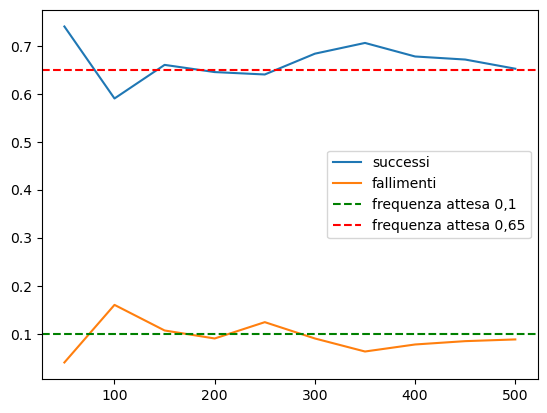

In [25]:
plt.plot(test, successi, label='successi')
plt.plot(test, fallimenti, label='fallimenti')
plt.axhline(0.10, color='g', linestyle='--', label='frequenza attesa 0,1')
plt.axhline(0.65, color='r', linestyle='--', label='frequenza attesa 0,65')
plt.legend()


## Esercizio 3

1. Genera una matrice NumPy di dimensioni 6 × 8, con valori estratti da una distribuzione normale con media = 50 e deviazione standard = 10.

2. Per ogni riga, individua il valore massimo e il valore minimo.

3. Costruisci un array contenente, per ogni riga, la differenza tra il valore massimo e il valore minimo.

4. Calcola quante righe hanno una differenza maggiore di 20.

In [40]:
matrix = np.reshape(np.random.normal(50,10,6*8), (6,8))

tmp=[]
for line in matrix:
    max = line.max()
    min = line.min()
    print(min, max)
    tmp.append(max-min)

new = np.reshape(tmp, (6,1))
print(new)

print(new[new>20].shape[0])

25.625355422341407 61.51151461610986
30.363849373364673 69.32370332664095
37.097415191074745 69.60913744314468
38.886766885882636 62.75549279410529
23.846290742398683 60.14269107652176
32.87915137961592 67.05586302486809
[[35.88615919]
 [38.95985395]
 [32.51172225]
 [23.86872591]
 [36.29640033]
 [34.17671165]]
6


## Esercizio 4

Utilizza il dataset `heroes.csv`, che contiene le seguenti colonne:

`hero_id`, `hero`, `universe`, `strength`, `speed`, `intelligence`, `missions`, `success_rate`, `power_type`.

1. Verifica la presenza di **valori mancanti per colonna** ed elimina le righe che ne contengono.

2. Crea una nuova colonna `mission_score` definita come:

   $$
   \texttt{mission\_score}
   =
   \texttt{missions}
   \times
   \texttt{success\_rate}
   $$

3. Calcola il valore medio di `mission_score` per ciascun universo (`Marvel` e `DC`) e determina quale universo ha il valore medio più elevato.

4. Crea un **grafico a barre** che mostri il valore medio di `mission_score` per ciascun universo.

5. Crea uno **scatter plot** con:
   - asse x = `strength`
   - asse y = `success_rate`
   - colore dei punti = `mission_score`

In [42]:
data = pd.read_csv('heroes.csv')
data.head()

,hero_id,hero,universe,strength,speed,intelligence,missions,success_rate,power_type
0,1,Hero_1,Marvel,81.2,68.5,63.1,182.0,85.6,Mutation
1,2,Hero_2,DC,75.8,88.8,78.6,207.4,89.4,Speed
2,3,Hero_3,DC,95.0,57.6,94.4,228.1,81.9,Technology
3,4,Hero_4,Marvel,73.3,93.9,73.4,231.9,94.9,Speed
4,5,Hero_5,DC,58.5,95.0,77.3,212.7,81.7,Speed


In [47]:
print(data.isna().sum())
data.dropna(inplace=True) #li ho tolti (prima ce n'erano ma ho ristampato per sbaglio)

hero_id         0
hero            0
universe        0
strength        0
speed           0
intelligence    0
missions        0
success_rate    0
power_type      0
dtype: int64


In [49]:
data['mission_score']=data.missions*data.success_rate
data.head(2)

,hero_id,hero,universe,strength,speed,intelligence,missions,success_rate,power_type,mission_score
0,1,Hero_1,Marvel,81.2,68.5,63.1,182.0,85.6,Mutation,15579.20
1,2,Hero_2,DC,75.8,88.8,78.6,207.4,89.4,Speed,18541.56


In [67]:
print(data.groupby('universe')['mission_score'].mean())

y = data.groupby('universe')['mission_score'].mean()
y = [float(i) for i in y.values]
groups = [str(i) for i in data.universe.unique()]
print(groups)

universe
DC        18709.714000
Marvel    18127.898936
Name: mission_score, dtype: float64
['Marvel', 'DC']


<BarContainer object of 2 artists>

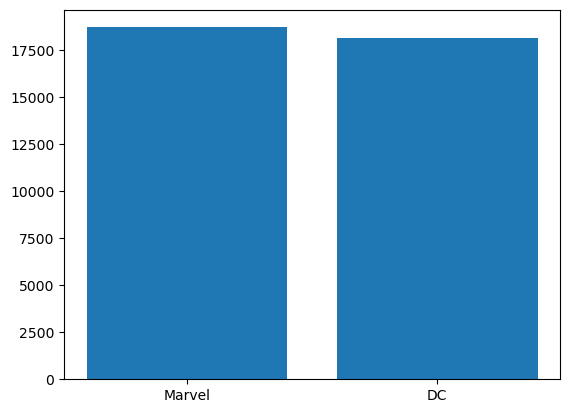

In [68]:
plt.bar(groups, y)

Text(0, 0.5, 'success_rate')

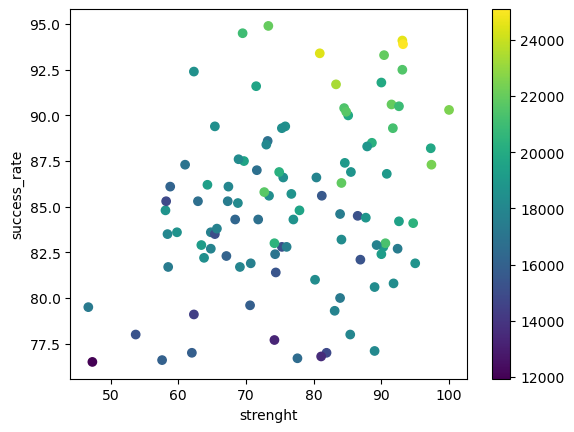

In [71]:
plt.scatter(x=data.strength.values, y=data.success_rate.values, c=data.mission_score)
plt.colorbar()
plt.xlabel('strenght')
plt.ylabel('success_rate')

## Esercizio 5

**Prima di svolgere questo esercizio, ricaricare il dataset originale `heroes.csv`.**

Si utilizzi di nuovo il dataset `heroes.csv`.

Svolgere le seguenti richieste:

1. Determinare il numero di righe e di colonne del dataset ed eliminare la colonna `hero_id`.
2. Individuare il `power_type` più frequente nel dataset.
3. Calcolare la media di `success_rate` per ciascun `power_type` e ordinare i risultati dal valore medio più alto al più basso.
4. Rappresentare la distribuzione di `success_rate` per ciascun `power_type` mediante un boxplot.
5. Calcolare la percentuale di eroi con `success_rate >= 90` e con `success_rate < 90` **usando una list comprehension**, e rappresentare tali percentuali con un grafico a torta (pie chart).


In [ ]:
data = pd.read_csv('heroes.csv')

In [ ]:
print(data.info()) #120 osservazioni, 9 variabili

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   hero_id       120 non-null    int64  
 1   hero          120 non-null    str    
 2   universe      120 non-null    str    
 3   strength      120 non-null    float64
 4   speed         115 non-null    float64
 5   intelligence  120 non-null    float64
 6   missions      115 non-null    float64
 7   success_rate  115 non-null    float64
 8   power_type    115 non-null    str    
dtypes: float64(5), int64(1), str(3)
memory usage: 10.6 KB
None


In [84]:
data.head(2)
data.drop(labels='hero_id',axis=1, inplace=True)
data.head(2)

,hero,universe,strength,speed,intelligence,missions,success_rate,power_type
0,Hero_1,Marvel,81.2,68.5,63.1,182.0,85.6,Mutation
1,Hero_2,DC,75.8,88.8,78.6,207.4,89.4,Speed


In [99]:
data.dropna(inplace=True)
data.power_type.value_counts()
print(data.power_type.value_counts().index[0])

Mutation


In [107]:
tmp = data.groupby('power_type')['success_rate'].mean()
print(tmp)
print(tmp.sort_values(ascending=False))

power_type
Alien         87.323529
Magic         83.852941
Mutation      84.773077
Skill         85.153333
Speed         85.012500
Technology    83.881818
Name: success_rate, dtype: float64
power_type
Alien         87.323529
Skill         85.153333
Speed         85.012500
Mutation      84.773077
Technology    83.881818
Magic         83.852941
Name: success_rate, dtype: float64


<Axes: xlabel='power_type', ylabel='success_rate'>

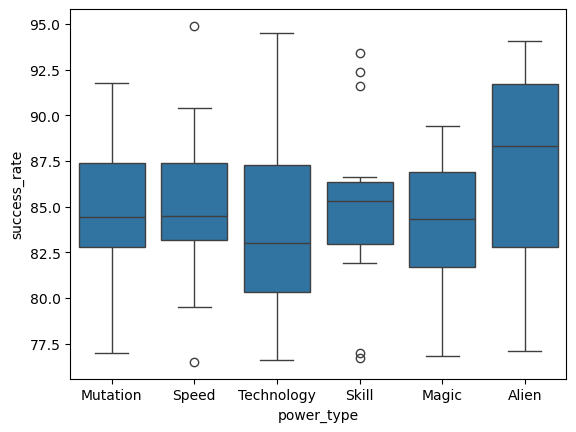

In [114]:
sns.boxplot(data=data, x='power_type', y='success_rate')

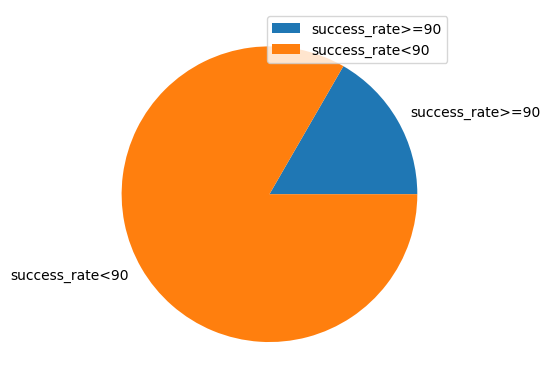

In [122]:
success_moreeq90 = len([i for i in data.success_rate if i>=90])
success_less90 = len([i for i in data.success_rate if i<90])
freq1 = success_moreeq90/(success_moreeq90+success_less90)
freq2 = success_less90/(success_moreeq90+success_less90)

plt.pie(x=[freq1, freq2], labels=['success_rate>=90', 'success_rate<90'])
plt.legend()

## Esercizio 6

Hai a disposizione il dataset di coppie `(x, y)` qui sotto riportato.

1. Stima i parametri della retta del tipo

   $$
   y = a \cdot x + b
   $$

   usando `scipy.optimize.curve_fit`.
2. Plotta i punti originali e la retta ottenuta.
3. Calcola **MAE** (Mean Absolute Error) e **RMSE** (Root Mean Squared Error) tra i valori reali `y` e quelli stimati dal modello, dove:

   $$
   \text{MAE} = \frac{1}{n}\sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert
   $$  

   $$
   \text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
   $$


In [123]:
x = np.array([
    0.0, 0.5, 1.0, 1.5, 2.0, 2.5,
    3.0, 3.5, 4.0, 4.5, 5.0, 5.5,
    6.0, 6.5, 7.0, 7.5, 8.0, 8.5,
    9.0, 9.5, 10.0
])

y = np.array([
    2.1, 3.2, 4.7, 6.0, 7.5, 8.8,
    10.2, 12.0, 13.1, 14.9, 16.3, 17.8,
    19.0, 20.7, 22.1, 23.6, 25.2, 26.4,
    28.0, 29.3, 31.1
])


In [ ]:
def lineare(x, m, q):
    return m*x + q

popt, _ = sp.optimize.curve_fit(lineare, x, y)
m = popt[0]
q = popt[1]

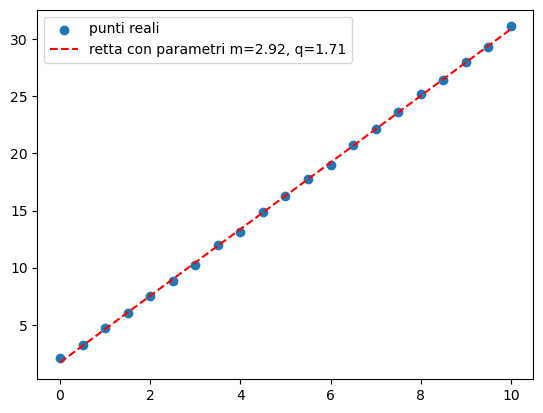

In [137]:
plt.scatter(x,y, label='punti reali')
plt.plot(x, lineare(x, m, q), color='r', linestyle="--", label = 'retta con parametri m={}, q={}'.format(round(m,2),round(q, 2)))
plt.legend()

In [141]:
y_pred = lineare(x, m, q)
mae = np.mean(np.abs(y-y_pred))
rmse=np.sqrt(np.mean((y - y_pred)**2))

print(mae, rmse)

0.11955473080574522 0.15595973347725214
